In [ ]:
import muspan as ms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import cv2

from roifile import roiread
from persim import plot_diagrams

from filters import cycle_intensity, edge_strength, component_intensity, hole_strength, basic_filtering

print("Packages loaded successfully!")

Packages loaded successfully!


Image is 500 wide and 415 tall
[[252. 255.]
 [252. 255.]
 [245. 255.]
 [242. 248.]
 [238. 255.]
 [235. 255.]
 [235. 255.]
 [223. 249.]
 [223. 255.]
 [210. 215.]
 [208. 255.]
 [207. 255.]
 [207. 241.]
 [203. 237.]
 [201. 255.]
 [199. 255.]
 [197. 212.]
 [196. 204.]
 [183. 188.]
 [175. 255.]
 [167. 208.]
 [160. 199.]
 [160. 165.]
 [159. 240.]
 [153. 162.]
 [150. 201.]
 [148. 231.]
 [142. 212.]
 [141. 255.]
 [140. 174.]
 [133. 193.]
 [131. 250.]
 [114. 160.]
 [114. 120.]
 [101. 255.]
 [100. 151.]
 [ 98. 150.]
 [ 96. 102.]
 [ 83. 144.]
 [ 81. 122.]
 [ 80. 124.]
 [ 65. 156.]
 [ 64.  71.]
 [ 64. 102.]
 [ 61.  81.]
 [ 61.  71.]
 [ 61.  77.]
 [ 61.  71.]
 [ 60.  95.]
 [ 58. 221.]
 [ 56.  62.]
 [ 55.  72.]
 [ 55.  82.]
 [ 53.  61.]
 [ 53.  83.]
 [ 51.  62.]
 [ 51.  78.]
 [ 51.  68.]
 [ 51.  92.]
 [ 51. 135.]
 [ 50.  67.]
 [ 49.  61.]
 [ 49. 225.]
 [ 48. 255.]
 [ 47.  61.]
 [ 47.  53.]
 [ 47.  94.]
 [ 46.  71.]
 [ 45.  79.]
 [ 45. 139.]
 [ 42. 255.]
 [ 42. 116.]
 [ 41.  64.]
 [ 40.  48.]
 [ 40. 

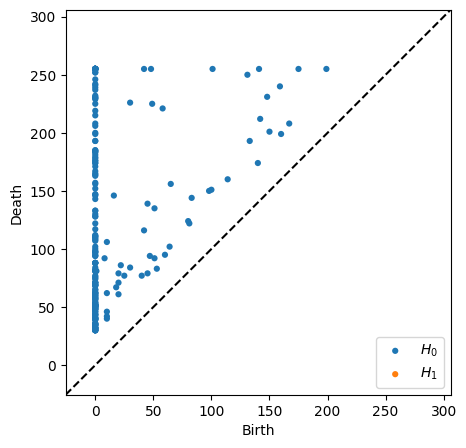

Image is 500 wide and 620 tall
[[254. 255.]
 [254. 255.]
 [253. 255.]
 ...
 [  0. 255.]
 [  0.  25.]
 [  0.  47.]]
Number of components before: 2018
Number of components after filtering: 1124
Number of cycles before: 63
Number of cycles after filtering: 15


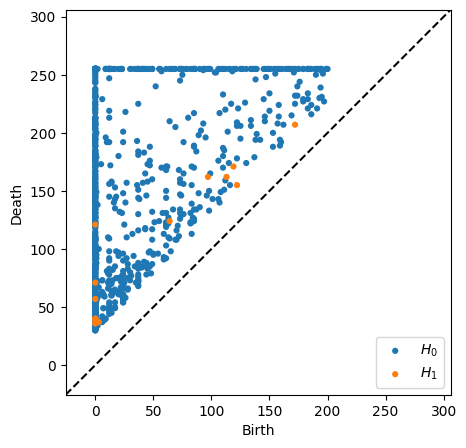

Image is 500 wide and 550 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0.   4.]
 [  0.  48.]
 [  0.   2.]]
Number of components before: 2993
Number of components after filtering: 1501
Number of cycles before: 169
Number of cycles after filtering: 45


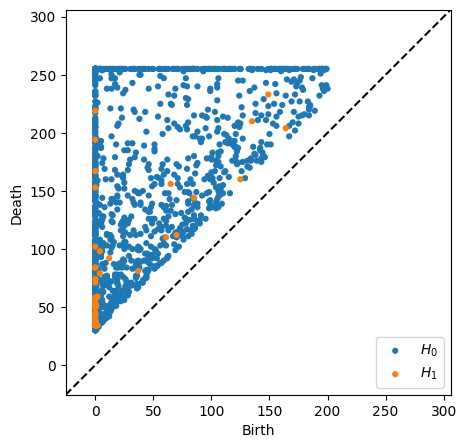

Image is 500 wide and 586 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0.   2.]
 [  0. 105.]
 [  0.  58.]]
Number of components before: 2902
Number of components after filtering: 976
Number of cycles before: 246
Number of cycles after filtering: 57


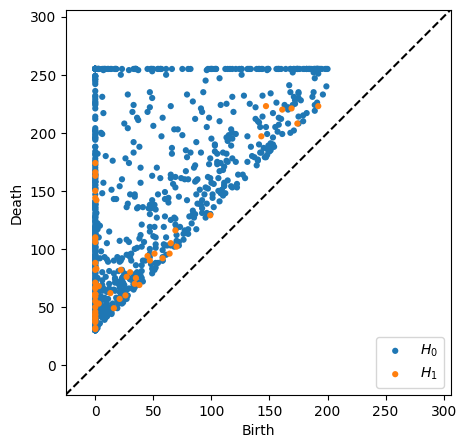

Image is 500 wide and 621 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0.   3.]
 [  0.   2.]
 [  0.   1.]]
Number of components before: 11618
Number of components after filtering: 1230
Number of cycles before: 3575
Number of cycles after filtering: 213


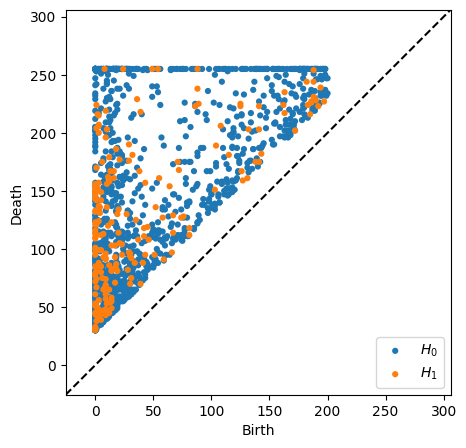

Image is 500 wide and 695 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0. 143.]
 [  0.  77.]
 [  0.  64.]]
Number of components before: 1678
Number of components after filtering: 1029
Number of cycles before: 172
Number of cycles after filtering: 95


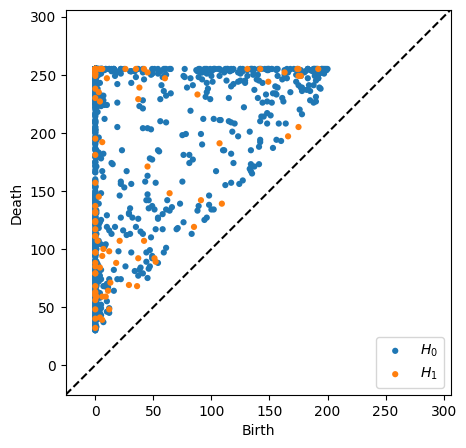

Image is 500 wide and 623 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0.   2.]
 [  0.   1.]
 [  0.  25.]]
Number of components before: 1100
Number of components after filtering: 536
Number of cycles before: 365
Number of cycles after filtering: 180


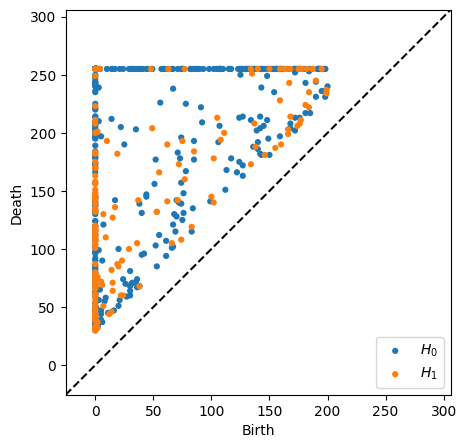

Image is 500 wide and 695 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0.  13.]
 [  0.  32.]
 [  0.  28.]]
Number of components before: 2721
Number of components after filtering: 718
Number of cycles before: 568
Number of cycles after filtering: 153


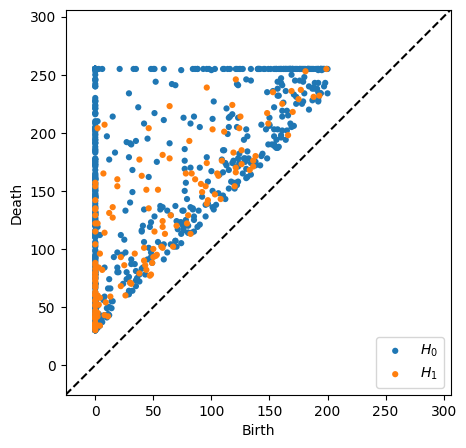

Image is 500 wide and 793 tall
[[254. 255.]
 [254. 255.]
 [254. 255.]
 ...
 [  0.  78.]
 [  0.   8.]
 [  0.   5.]]
Number of components before: 892
Number of components after filtering: 481
Number of cycles before: 148
Number of cycles after filtering: 75


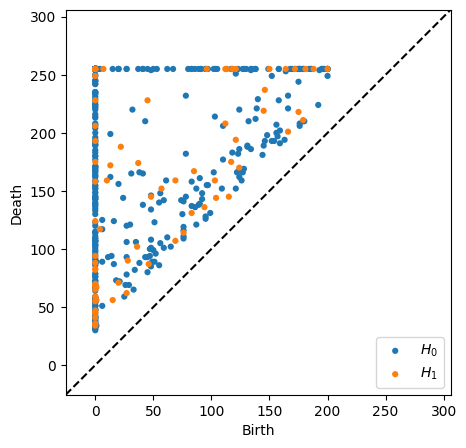

In [23]:
n=1
path = f"data/PH scaled/{n}"
stages = [3,4,5,6,8,9,10,11,12]
new_width = 500

components_strength_hh = []
strong_components_hh = []
weak_edges_hh = []
edges_strength_hh = []
cycles_strength_hh = []
components_hh = []
cycles_hh = []
vectors = []

for stage in stages:
    #image = cv2.imread(f'data/ph_test_cycles.png') #test image
    image = cv2.imread(f'data/PH scaled/{n}/hh{stage}BCblur.png')
    background_colour = "black"

    height = len(image)
    width = len(image[0])

    new_height = int(new_width/width * height)
    #plt.imshow(image)
    image = cv2.resize(image, (new_width,new_height)) #downscale to not crash python
    if background_colour == "white": #invert image so we can filter in right direction (PH filters from black to white)
        image = 255-image

    grey_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    print(f"Image is {len(image[0])} wide and {len(image)} tall")
    #print(np.max(grey_image))



    #run PH
    result = ms.topology.level_set_filtration(grey_image) 
     
    fig,ax=plt.subplots(figsize=(5,5))

    cycles = result["dgms"][0] #reverse the cycle and components (because we filtered black to white instead of white to black: hacky workaround)
    components = result["dgms"][1]

    cycles = cycles[[ r[1]<999 for r in cycles]] #remove the infinite cycle generated
    #print(components)
    #print("\n")
    #print(cycles)

    #plot_diagrams([components, cycles], show=True)
    # plot_diagrams([cycles], show=True)

    [components,cycles] = basic_filtering(components,cycles,plot=True)
    #filtered_persistence = {"dgms":[components,cycles]}
    #ms.visualise.barcode(filtered_persistence)

    components_hh.append(len(components))
    cycles_hh.append(len(cycles))

    comp_strength = component_strength(components)
    #print(comp_strength)
    components_strength_hh.append(comp_strength)
    
    ed_strength = edge_strength(components)
    #print(ed_strength)
    edges_strength_hh.append(ed_strength)

    cyc_strength = cycle_strength(cycles)
    #print(cyc_strength)
    cycles_strength_hh.append(cyc_strength)


    vectorised_ph,_ = ms.topology.vectorise_persistence(result, method='statistics')
    vectors.append(vectorised_ph)


[103.5 114.   91.   83.5  88.   28.    0.   76.5  45. ]


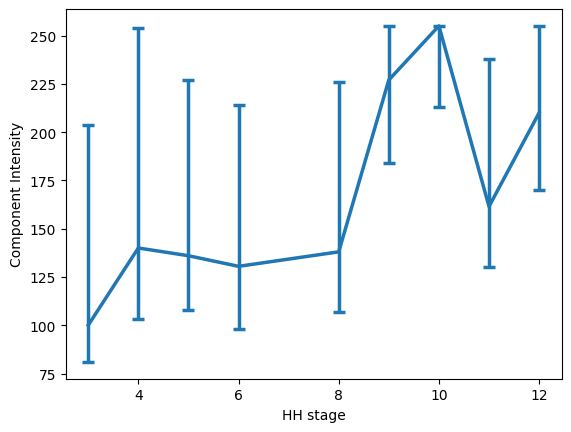

In [24]:
#plt.violinplot(components_strength_hh,stages,showmedians=True)
#plt.violinplot([components_strength_hh[1], components_strength_hh[3], components_strength_hh[7]],showmedians=True)
#plt.plot(components_strength_hh[0])
#plt.plot(stages,cycles_hh)

#mean + error bars


medians = [np.median(i) for i in components_strength_hh]
lower_percentile = np.subtract(medians,[np.percentile(i,40) for i in components_strength_hh])
upper_percentile = np.subtract([np.percentile(i,75) for i in components_strength_hh],medians)
print(upper_percentile)
#plt.plot(upper_percentile)
plt.errorbar(stages,medians,yerr=[lower_percentile,upper_percentile],linewidth=2.5,capsize=4,capthick=2.5)
plt.xlabel("HH stage")
plt.ylabel("Component Intensity")
    

means = [np.mean(i) for i in components_strength_hh]
stds = [np.std(i) for i in components_strength_hh]
#plt.errorbar(stages,means,yerr=stds)


<ErrorbarContainer object of 3 artists>

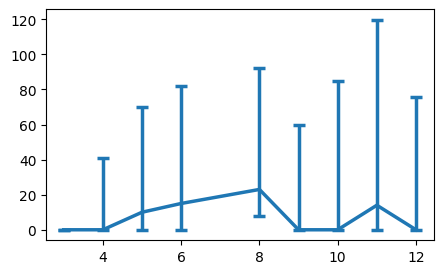

In [25]:
medians = [np.median(i) for i in edges_strength_hh]
lower_percentile = np.subtract(medians,[np.percentile(i,25) for i in edges_strength_hh])
upper_percentile = np.subtract([np.percentile(i,75) for i in edges_strength_hh],medians)
#plt.plot(upper_percentile)
fig,ax=plt.subplots(figsize=(5,3))
plt.errorbar(stages,medians,yerr=[lower_percentile,upper_percentile],linewidth=2.5,capsize=4,capthick=2.5)

[[], [np.float64(36.0), np.float64(36.0), np.float64(37.0), np.float64(39.0), np.float64(40.0), np.float64(40.0), np.float64(57.0), np.float64(71.0), np.float64(121.0), np.float64(124.0), np.float64(155.0), np.float64(162.0), np.float64(162.0), np.float64(171.0), np.float64(207.0)], [np.float64(34.0), np.float64(34.0), np.float64(34.0), np.float64(36.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(38.0), np.float64(38.0), np.float64(39.0), np.float64(42.0), np.float64(43.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(49.0), np.float64(51.0), np.float64(52.0), np.float64(53.0), np.float64(56.0), np.float64(58.0), np.float64(58.0), np.float64(59.0), np.float64(71.0), np.float64(74.0), np.float64(74.0), np.float64(79.0), np.float64(81.0), np.float64(84.0), np.float64(84.0), np.float64(92.0), np.float64(98.0), np.float64(102.0), np.float64(110.0), np.float64(112.0), np.float64(144.0), np.float64(153.0), np.float64(156.0), np.float64(160.0), np.flo

Text(0, 0.5, 'Cycle Intensity')

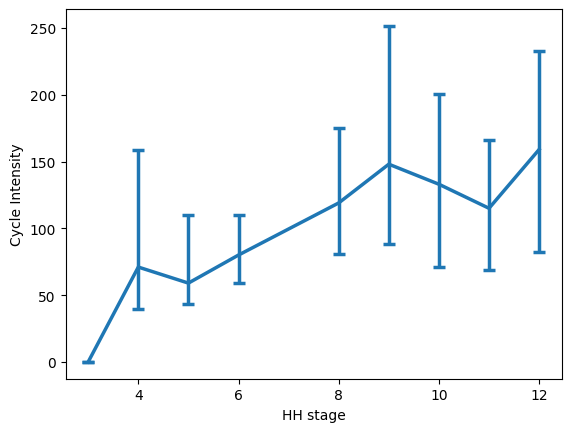

In [26]:
print(cycles_strength_hh)
cycles_strength_hh[0] = [0]
medians = [np.median(i) for i in cycles_strength_hh]
lower_percentile =  np.subtract(medians,[np.percentile(i,25) for i in cycles_strength_hh])
upper_percentile =  np.subtract([np.percentile(i,75) for i in cycles_strength_hh],medians)
#plt.plot(upper_percentile)
plt.errorbar(stages,medians,yerr=[lower_percentile,upper_percentile],linewidth=2.5,capsize=4,capthick=2.5)
plt.xlabel("HH stage")
plt.ylabel("Cycle Intensity")

[np.float64(199.0), np.float64(175.0), np.float64(167.0), np.float64(160.0), np.float64(159.0), np.float64(150.0), np.float64(148.0), np.float64(142.0), np.float64(141.0), np.float64(140.0), np.float64(133.0), np.float64(131.0), np.float64(114.0), np.float64(101.0), np.float64(100.0), np.float64(98.0), np.float64(83.0), np.float64(81.0), np.float64(80.0), np.float64(65.0), np.float64(64.0), np.float64(60.0), np.float64(58.0), np.float64(53.0), np.float64(51.0), np.float64(51.0), np.float64(49.0), np.float64(48.0), np.float64(47.0), np.float64(45.0), np.float64(45.0), np.float64(42.0), np.float64(42.0), np.float64(40.0), np.float64(30.0), np.float64(30.0), np.float64(25.0), np.float64(22.0), np.float64(20.0), np.float64(20.0), np.float64(20.0), np.float64(18.0), np.float64(16.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(8.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), n

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x23f2ffc9090>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x23f2ffd4090>,
 'cmins': <matplotlib.collections.LineCollection at 0x23f30021ad0>,
 'cbars': <matplotlib.collections.LineCollection at 0x23f2ffcaad0>,
 'cmedians': <matplotlib.collections.LineCollection at 0x23f30005c90>}

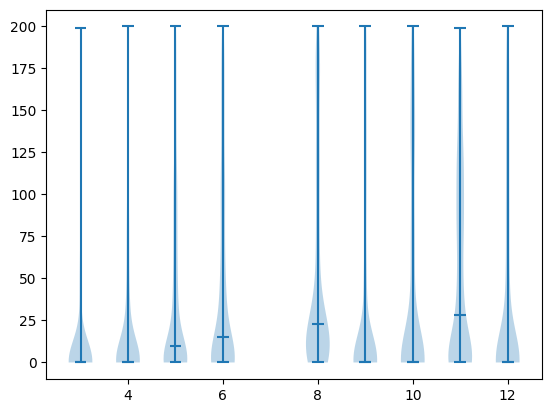

In [12]:
print(edges_strength_hh[0])
plt.violinplot(edges_strength_hh,stages,showmedians=True)

Text(0.5, 1.0, 'PCA of Vectorised Persistence Diagrams')

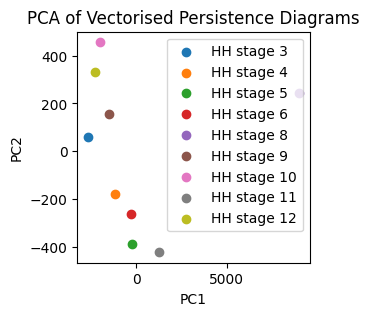

In [25]:
from sklearn.decomposition import PCA
import numpy as np


# Combine all vectorised persistence diagrams into a single array
#vectorised_ph_all = np.vstack([vectorised_ph_1, vectorised_ph_2, vectorised_ph_3, vectorised_ph_4])

# Perform PCA to reduce the dimensionality to 2 components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(vectors)

# Plot the PCA result
fig, ax = plt.subplots(figsize=(3, 3))
n=0
for stage in stages:
    ax.scatter(pca_result[n, 0], pca_result[n, 1], label=f'HH stage {stage}')
    n=n+1

# Add labels and title to the plot
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('PCA of Vectorised Persistence Diagrams')

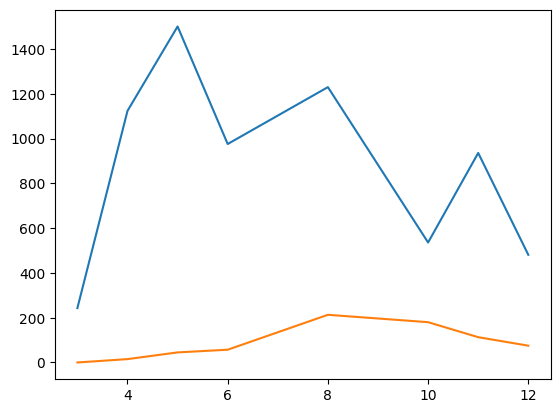

In [11]:
plt.plot(stages,components_hh)
plt.plot(stages,cycles_hh)



In [13]:
plt.plot(stages,strong_components_hh)
plt.plot(stages,weak_components_hh)

: 

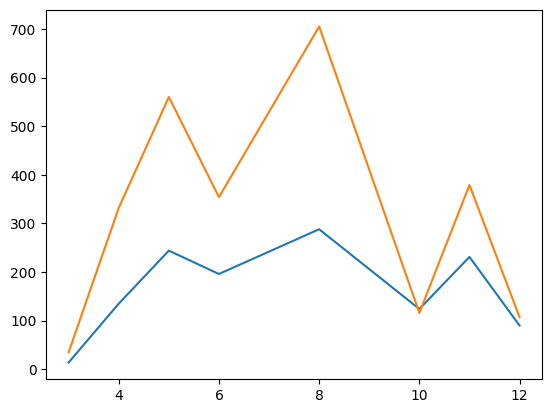

In [17]:
plt.plot(stages,strong_edges_hh)
plt.plot(stages,weak_edges_hh)

In [5]:
def level_set_image(image,a):
    newim=np.copy(image)
    for i in range(len(image)):
        for j in range(len(image[0])):
            if image[i,j] >= 255-a:
                newim[i,j] = 255
    return newim

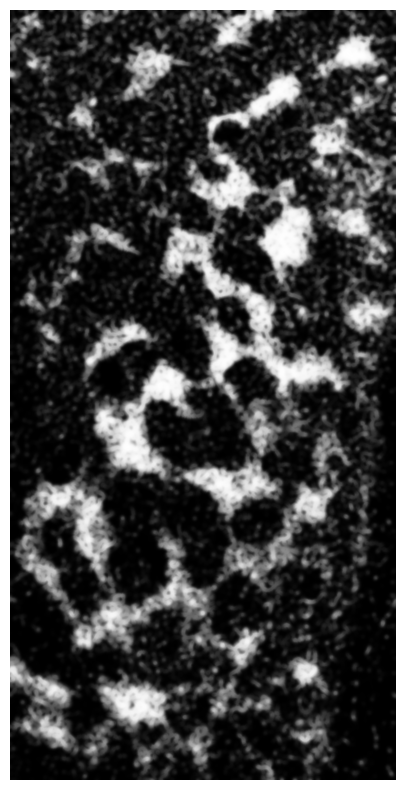

In [10]:
image = cv2.imread(f'data/PH scaled/test/hh6flattened_blur2.png')
fig, ax = plt.subplots(figsize=(5, 10))
plt.axis('off')
grey_image = 255-cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(grey_image)
new_image = level_set_image(grey_image,0)
plt.imshow(new_image,cmap="Greys")

new_image = level_set_image(grey_image,100)
#plt.imshow(new_image,cmap="Greys")


new_image = level_set_image(grey_image,200)
#plt.imshow(new_image,cmap="Greys")



In [4]:
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt
from sklearn import datasets


all = ripser(test2,distance_matrix=True)
dgms = all["dgms"][0]
plot_diagrams(dgms, show=True)
print(dgms)

NameError: name 'test2' is not defined

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='$r$', ylabel='Feature Number'>)

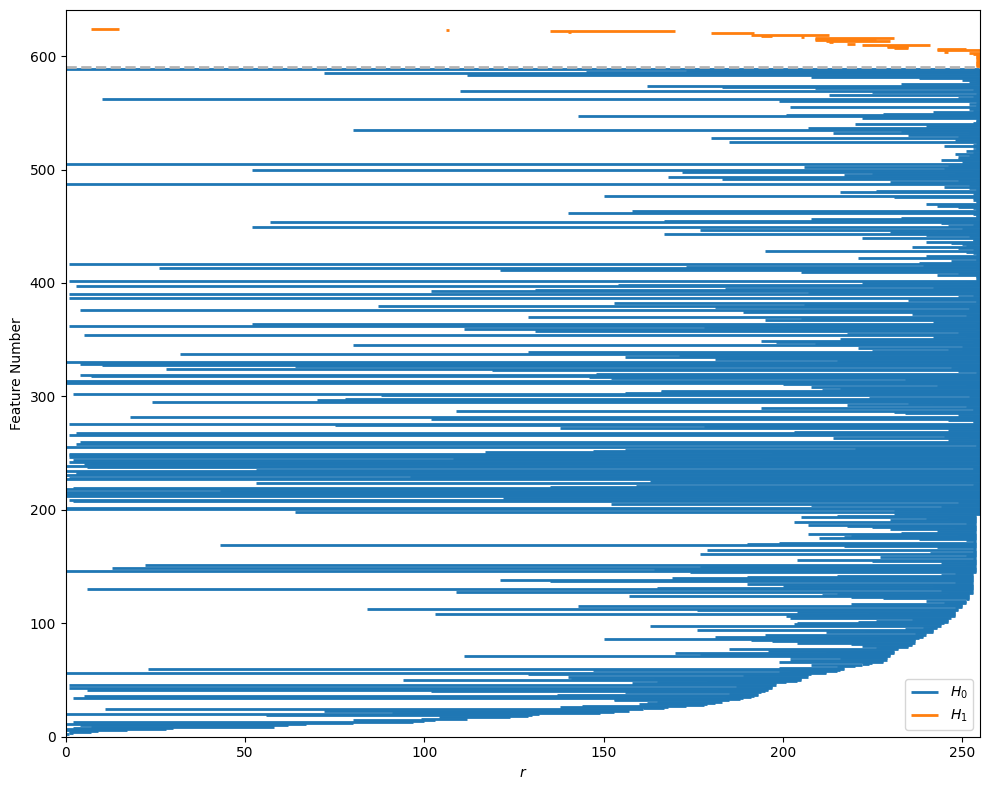

In [23]:
ms.visualise.barcode(result)